In [3]:
import pandas as pd

data = pd.read_csv("student_dropout_cleaned.csv")

data.head()

,Student_ID,Age,Gender,Family_Income,Internet_Access,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Part_Time_Job,Scholarship,Stress_Index,GPA,Semester_GPA,CGPA,Semester,Department,Parental_Education,Dropout
0,1,22.1,Male,25000.0,Yes,3.36,86.1,2,20.4,Yes,No,5.5,0.96,0.90,0.90,Year 1,Arts,High School,0
1,2,20.7,Male,25000.0,Yes,4.30,68.0,2,44.0,No,No,6.8,1.28,1.20,1.19,Year 3,Engineering,Bachelor,1
2,3,22.4,Male,40183.0,Yes,4.40,70.9,0,48.9,Yes,No,5.5,1.68,1.32,1.32,Year 1,Arts,Master,0
3,5,20.5,Female,25319.0,Yes,4.19,75.7,1,23.0,No,No,7.0,1.48,0.91,0.87,Year 4,Business,Bachelor,0
4,7,24.5,Male,25000.0,Yes,3.00,78.2,1,37.4,Yes,Yes,7.3,0.64,0.33,0.44,Year 4,CS,Bachelor,0


## 2.1 Zielvariable

Für dieses Projekt soll vorhergesagt werden, ob ein Student das Studium abbricht oder nicht.  
Dafür wird das Feld **Dropout** verwendet. Dieses Feld enthält die Werte 0 (kein Abbruch) und 1 (Abbruch).

## 2.2 Statistische Informationen

Für die numerischen Felder werden statistische Kennzahlen berechnet. Dazu gehören unter anderem Mittelwert, Median, Standardabweichung, Minimum und Maximum.

In [4]:
data.describe()

,Student_ID,Age,Family_Income,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Stress_Index,GPA,Semester_GPA,CGPA,Dropout
count,9020.000000,9020.000000,9020.000000,9020.000000,9020.000000,9020.000000,9020.000000,9020.000000,9020.000000,9020.000000,9020.000000,9020.000000
mean,4987.913193,21.025754,38443.460532,4.016183,81.971563,1.800776,30.153847,5.504202,2.307942,2.300035,2.298906,0.234812
std,2888.368995,2.141807,20618.661013,1.294489,7.988880,1.349337,11.960170,1.767680,1.061883,1.074079,1.072379,0.423904
min,1.000000,17.000000,25000.000000,0.500000,50.000000,0.000000,5.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,2479.750000,19.500000,25000.000000,3.160000,76.600000,1.000000,21.800000,4.300000,1.550000,1.520000,1.520000,0.000000
50%,4969.000000,21.000000,29764.000000,4.010000,82.000000,2.000000,30.100000,5.500000,2.340000,2.350000,2.350000,0.000000
75%,7491.250000,22.500000,44569.250000,4.870000,87.500000,3.000000,38.400000,6.700000,3.120000,3.150000,3.150000,0.000000
max,10000.000000,29.600000,316601.000000,8.980000,100.000000,8.000000,74.900000,10.000000,4.000000,4.000000,4.000000,1.000000


In [5]:
data.median(numeric_only=True)

Student_ID                4969.00
Age                         21.00
Family_Income            29764.00
Study_Hours_per_Day          4.01
Attendance_Rate             82.00
Assignment_Delay_Days        2.00
Travel_Time_Minutes         30.10
Stress_Index                 5.50
GPA                          2.34
Semester_GPA                 2.35
CGPA                         2.35
Dropout                      0.00
dtype: float64

In [6]:
data.std(numeric_only=True)

Student_ID                2888.368995
Age                          2.141807
Family_Income            20618.661013
Study_Hours_per_Day          1.294489
Attendance_Rate              7.988880
Assignment_Delay_Days        1.349337
Travel_Time_Minutes         11.960170
Stress_Index                 1.767680
GPA                          1.061883
Semester_GPA                 1.074079
CGPA                         1.072379
Dropout                      0.423904
dtype: float64

## 2.3 Grafik

Zur besseren Analyse der Daten wird ein Histogramm für das Feld GPA erstellt. Dadurch sieht man, wie die Notendurchschnitte der Studierenden verteilt sind.

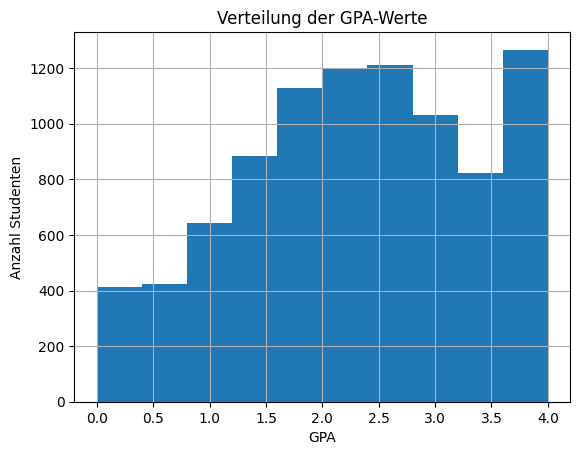

In [7]:
import matplotlib.pyplot as plt

data["GPA"].hist()
plt.title("Verteilung der GPA-Werte")
plt.xlabel("GPA")
plt.ylabel("Anzahl Studenten")
plt.show()

## 2.4 Skalierung der Daten

Das Feld Study_Hours_per_Day wurde mit dem StandardScaler aus der sklearn-Bibliothek skaliert. Dabei werden die Werte so umgerechnet, dass sie einen Mittelwert von 0 und eine Standardabweichung von 1 haben. Das ist für viele Machine-Learning-Algorithmen hilfreich, weil numerische Merkmale dadurch besser vergleichbar werden. Besonders bei Algorithmen, die mit Abständen oder Gewichtungen arbeiten, kann eine Skalierung wichtig sein. In diesem Projekt wurde Study_Hours_per_Day beispielhaft skaliert, um die Daten für die spätere Verarbeitung vorzubereiten.

In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

data["Study_Hours_per_Day_scaled"] = scaler.fit_transform(data[["Study_Hours_per_Day"]])

data[["Study_Hours_per_Day", "Study_Hours_per_Day_scaled"]].head()

,Study_Hours_per_Day,Study_Hours_per_Day_scaled
0,3.36,-0.506933
1,4.30,0.219262
2,4.40,0.296517
3,4.19,0.134282
4,3.00,-0.785051
